Многослойный персептрон
--
Реализовать архитектуру многослойного персептрона. Реализовать алгоритм обратного распространения ошибки для обучения сети.



## 1. Многослойный персептрон-регрессор

Нужно сделать:\
а) Обработать датасет по алгоритму из 1-й лабораторной работы;\
б) Обучить на очищенном датасете. Реализовать перцептрон-регрессор.

Возьмём за основу тот же датасет, который мы использовали в предыдущей работе - "Цены на лаптопы". Проделаем с ним ту же работу по подготовке и работе.

### I. Обработка датасета.

Используем библиотеки:

In [ ]:
import pandas as pd # Обработка и анализ данных с файла
import numpy as np  # Для работы с многомерными массивами, числовыми данными
import matplotlib.pyplot as plt # Визуализация данных
import seaborn as sns # Статические графики
from scipy.stats import zscore

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.feature_selection import SelectFromModel

print("Библиотеки успешно загружены!")

Библиотеки успешно загружены!


Проводим кодирование категориальных и масштабирование числовых признаков

In [ ]:
df = pd.read_csv("Laptop_price.csv")

# Кодирование

label_encoder = LabelEncoder()
df['Brand_encoded'] = label_encoder.fit_transform(df['Brand'])
print(f"Бренды закодированы: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

numeric_features = ['Processor_Speed', 'RAM_Size', 'Storage_Capacity',
                    'Screen_Size', 'Weight', 'Price', 'Brand_encoded']

# Масштабирование

scaler_standard = StandardScaler()

df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df[numeric_features]),
    columns=numeric_features
)
print("Данные нормализованы: диапазон [0, 1]")
print(f"После стандартизации - среднее: {df_scaled_standard['Processor_Speed'].mean():.3f}, "
      f"std: {df_scaled_standard['Processor_Speed'].std():.3f}")

Бренды закодированы: {'Acer': np.int64(0), 'Asus': np.int64(1), 'Dell': np.int64(2), 'HP': np.int64(3), 'Lenovo': np.int64(4)}
Данные нормализованы: диапазон [0, 1]
После стандартизации - среднее: -0.000, std: 1.001


### II. Обучение модели персептрона-регрессора.

Будет использовать MLPResgressor из библиотеки scikit-learn:

Размер обучающей выборки: (700, 6)
Размер тестовой выборки: (300, 6)
R² на тесте: 0.9970
MSE на тесте: 0.0030
Количество итераций: 62
Финальная потеря: 0.0007


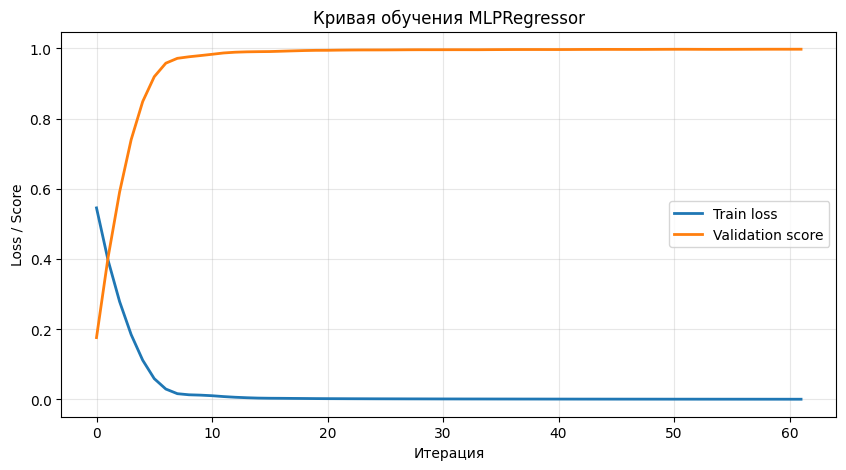

In [ ]:
from sklearn.neural_network import MLPRegressor

feature_columns = ['Processor_Speed', 'RAM_Size', 'Storage_Capacity',
                   'Screen_Size', 'Weight', 'Brand_encoded']
target_column = 'Price'

X = df[feature_columns]
y = df[target_column]

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Масштабирование
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_train)
y_scaled = scaler_y.fit_transform(y_train.to_numpy().reshape(-1, 1)).flatten()

scaler_X_test = StandardScaler()
scaler_y_test = StandardScaler()

X_test_scaled = scaler_X.fit_transform(X_test)
y_test_scaled = scaler_y.fit_transform(y_test.to_numpy().reshape(-1, 1)).flatten()


# Создание персептрона-регрессора
mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50), # два скрытых слоя: 100 и 50 нейронов
    activation='relu',            # функция активации ReLU
    learning_rate_init=0.001,     # начальная скорость обучения
    max_iter=250,                 # максимальное количество эпох
    random_state=42,
    early_stopping=True,          # ранняя остановка для предотвращения переобучения
)

# .fit() уже реализует обратное распространение ошибки
mlp.fit(X_scaled, y_scaled)

y_pred = mlp.predict(X_test_scaled)

# Оценка качества
print(f"R² на тесте: {r2_score(y_test_scaled, y_pred):.4f}")
print(f"MSE на тесте: {mean_squared_error(y_test_scaled, y_pred):.4f}")

# Анализ сходимости
print(f"Количество итераций: {mlp.n_iter_}")
print(f"Финальная потеря: {mlp.loss_:.4f}")


# Визуализация кривой потерь
plt.figure(figsize=(10, 5))
plt.plot(mlp.loss_curve_, label='Train loss', linewidth=2)
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_:
    plt.plot(mlp.validation_scores_, label='Validation score', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss / Score')
plt.title('Кривая обучения MLPRegressor')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



Что происходит внутри MLPRegressor.fit():
1. Инициализация весов
2. Прямое распространение (forward propagation)
3. Вычисление ошибки (loss)
4. Обратное распространение ошибки (backward propagation)
5. Обновление весов (optimization)
6. Повторение шагов 2-5 до сходимости

### III. Самостоятельная реализация персептрона

Ранее мы воспользовались реализацией персептрона и алгоритмом из библиотеки scikit-learn. Теперь поработаем над собственной реализацией.

Обучение завершено!
Размер обучающей выборки: (700, 6)
Размер тестовой выборки: (300, 6)
Начало обучения...
Эпоха 50/250, Loss: 0.261610
Эпоха 100/250, Loss: 0.177381
Эпоха 150/250, Loss: 0.138954
Эпоха 200/250, Loss: 0.115410
Эпоха 250/250, Loss: 0.099039
Финальный loss: 0.099039
R²: 0.9012

Результаты на тестовых данных:
R²: 0.8827
MSE: 0.1173


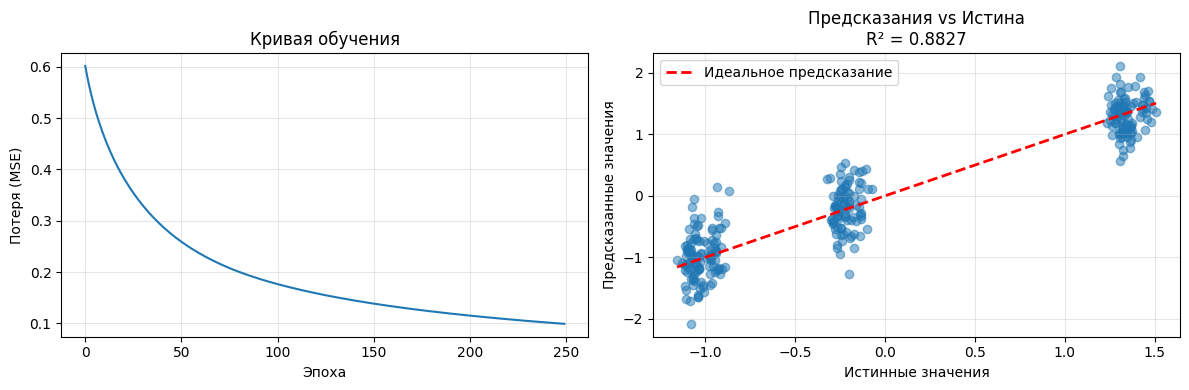

In [ ]:
class MyPerceptron():
  def __init__(self, hidden_layer_sizes=(100,50,25), activation='tanh',
                learning_rate=0.01, max_iter=100, random_state=42):
      """
      hidden_layer_sizes
          Количество нейронов в скрытых слоях
      activation
          Функция активации ('relu', 'sigmoid', 'tanh')
      learning_rate
          Скорость обучения
      max_iter
          Максимальное количество эпох
      """
      self.hidden_layer_sizes = hidden_layer_sizes
      self.activation = activation
      self.learning_rate = learning_rate
      self.max_iter = max_iter

      self.random_state = random_state
      self.weights = []     # Веса
      self.activations = [] # Выходы из нейронов
      self.z_values = []    # Входы в нейроны
      self.losses = []

  def activation_function(self, x):
    if self.activation == 'relu':
      return np.maximum(0, x)
    elif self.activation == "sigmoid":
      return 1 / (1 + np.exp(-x))
    elif self.activation == 'tanh':
      return np.tanh(x)
    else:
      raise ValueError(f"Unknown activation function: {self.activation}")

  def activation_derivative(self, z):
    if self.activation == 'relu':
      return (z > 0).astype(float)
    elif self.activation == "sigmoid":
      sig = 1 / (1 + np.exp(-np.clip(z, -500, 500)))
      return sig * (1 - sig)
    elif self.activation == 'tanh':
      return 1 - np.tanh(z) ** 2
    else:
      raise ValueError(f"Unknown activation function: {self.activation}")

  def _init_weights(self, input_dim, output_dim=1):
    # Если мы имеем n слоев (из которых 2 - входной и выходной),
    # то будем иметь n-1 "слой" весов
    # (и n-3 "слоя" весов только между n-1 скрытыми слоями нейронов)
    if self.random_state is not None:
      np.random.seed(self.random_state)

    layer_sizes = [input_dim] + list(self.hidden_layer_sizes) + [output_dim]

    for index in range(len(layer_sizes) - 1):
      input_size = layer_sizes[index]
      output_size = layer_sizes[index+1]

      scale = np.sqrt(2.0 / input_size) if self.activation == 'relu' else np.sqrt(1.0 / input_size)
      W = np.random.randn(input_size, output_size) * scale
      self.weights.append(W)

  def _forward(self, X):
    """
    Прямой путь от входа к выходу
    X - входные сигналы
    """

    # Очищаем векторы
    self.activations = [X]
    self.z_values = []

    current = X
    # Движение от входного слоя до последнего скрытого слоя
    for i in range(len(self.weights) - 1):
      z = current @ self.weights[i] # вектор посчитанных входов
      self.z_values.append(z)
      current = self.activation_function(z) # выход i-х нейронов
      self.activations.append(current)

    # Движение к выходному слою
    z = current @ self.weights[-1]
    self.z_values.append(z)
    output = z
    self.activations.append(output)

    return output

  def _backward(self, X, y, y_pred):
    M = X.shape[0]

    # Градиент
    grads_W = [None] * len(self.weights)

    # 0. Вычисление градиента выходного слоя
    # Вычисляем градиент выходного слоя через MSE
    delta = 2.0 * (y_pred - y) / M           # MSE
    grads_W[-1] = self.activations[-2].T @ delta # выход последнего скрытого слоя

    # I. Обратное распространение ошибки через скрытые слои
    for i in range(len(self.weights) - 2, -1, -1):
      delta = (delta @ self.weights[i+1].T) * self.activation_derivative(self.z_values[i])
      grads_W[i] = self.activations[i].T @ delta

    # II. Корректировка весов
    for i in range(len(self.weights)):
      self.weights[i] -= self.learning_rate * grads_W[i]

  def fit(self, X, y):
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1, 1)

    # Инициализация весов
    self._init_weights(X.shape[1])

    self.losses = []

    print("Начало обучения...")

    for epoch in range(self.max_iter):
      # Прямое распространение
      y_pred = self._forward(X)

      loss = np.mean((y_pred - y) ** 2)
      self.losses.append(loss)

      # Обратное распространение
      self._backward(X, y, y_pred)

      if (epoch + 1) % 50 == 0:
          print(f"Эпоха {epoch+1}/{self.max_iter}, Loss: {loss:.6f}")

  print("Обучение завершено!")

  def predict(self, X):
    X = np.asarray(X)
    return self._forward(X).flatten()

  def score(self, X, y):
    """
    Коэффициент детерминации R²

    X: входные данные
    y: истинные значения
    """
    y_pred = self.predict(X)
    y = np.asarray(y)

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    return 1 - (ss_res / ss_tot)


# ------ Основная программа ------

feature_columns = ['Processor_Speed', 'RAM_Size', 'Storage_Capacity',
                   'Screen_Size', 'Weight', 'Brand_encoded']
target_column = 'Price'

X = df[feature_columns]
y = df[target_column]

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Масштабирование
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_train)
y_scaled = scaler_y.fit_transform(y_train.to_numpy().reshape(-1, 1)).flatten()

scaler_X_test = StandardScaler()
scaler_y_test = StandardScaler()

X_test_scaled = scaler_X.fit_transform(X_test)
y_test_scaled = scaler_y.fit_transform(y_test.to_numpy().reshape(-1, 1)).flatten()


# Создаем и обучаем нашу реализацию
mlp_scratch = MyPerceptron(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    learning_rate=0.001,  # для масштабированных данных
    max_iter=250,
    random_state=42
)

mlp_scratch.fit(X_scaled, y_scaled)

# Ожидаемые результаты
print(f"Финальный loss: {mlp_scratch.losses[-1]:.6f}")
print(f"R²: {mlp_scratch.score(X_scaled, y_scaled):.4f}")

# Предсказания
#y_pred = mlp_scratch.predict(X_scaled)
y_pred = mlp_scratch.predict(X_test_scaled)

# Оценка
print(f"\nРезультаты на тестовых данных:")
print(f"R²: {r2_score(y_test_scaled, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test_scaled, y_pred):.4f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Кривая обучения
axes[0].plot(mlp_scratch.losses)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Потеря (MSE)')
axes[0].set_title('Кривая обучения')
axes[0].grid(True, alpha=0.3)

# Предсказания vs истинные значения
axes[1].scatter(y_test_scaled, y_pred, alpha=0.5)
axes[1].plot([y_test_scaled.min(), y_test_scaled.max()], [y_test_scaled.min(), y_test_scaled.max()],
             'r--', lw=2, label='Идеальное предсказание')
axes[1].set_xlabel('Истинные значения')
axes[1].set_ylabel('Предсказанные значения')
axes[1].set_title(f'Предсказания vs Истина\nR² = {r2_score(y_test_scaled, y_pred):.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()